# TB Detection System - Linear Model Training
**Tuberculosis Detection System** using Logistic Regression
- Project Team: Bayuputra Kurnia Adhyatma, Bryan Vincent, Richson Limec
- IMPORTANT: This is a Decision Support Tool, NOT a final medical diagnosis

In [1]:
# Import Required Libraries
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
# Configuration
IMG_SIZE = 128  # Image size for linear model (prevents RAM exhaustion)
TRAIN_DIR = './data/train'
TEST_DIR = './data/test'
MODEL_PATH = 'tb_linear_model.pkl'

# Train-Test Split Configuration
TRAIN_SPLIT_PERCENT = 0.75  # 75% training data
TEST_SPLIT_PERCENT = 0.25   # 25% test data
RANDOM_STATE = 42          # For reproducibility

print(f"Configuration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Train-Test Split: {TRAIN_SPLIT_PERCENT*100:.0f}% training, {TEST_SPLIT_PERCENT*100:.0f}% testing")
print(f"  Random State: {RANDOM_STATE}")

Configuration:
  Image Size: 128x128
  Train-Test Split: 75% training, 25% testing
  Random State: 42


In [3]:
# Data Loading Function
def load_and_flatten_images(base_dir):
    """
    Loads images from the specified directory, converts them to grayscale,
    resizes, flattens them to 1D arrays, and normalizes pixel values.
    """
    X = []
    y = []
    
    classes = {'Normal': 0, 'TB': 1}
    
    for class_name, label in classes.items():
        folder_path = os.path.join(base_dir, class_name)
        
        if not os.path.exists(folder_path):
            print(f"Warning: Directory not found - {folder_path}")
            continue
            
        print(f"Loading {class_name} images from {base_dir}...")
        
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            
            try:
                # Read image in grayscale
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue
                    
                # Resize image
                img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                
                # Flatten the 2D image array into 1D feature vector
                img_flattened = img_resized.flatten()
                
                X.append(img_flattened)
                y.append(label)
                
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                
    # Convert to numpy arrays and normalize
    return np.array(X) / 255.0, np.array(y)

In [4]:
# Step 1: Load Raw Data
print("="*60)
print("Loading and Preparing Data")
print("="*60)

# Load all images from training directory
X_all, y_all = load_and_flatten_images(TRAIN_DIR)

if len(X_all) == 0:
    print("\nERROR: No data loaded. Please check your data directories.")
else:
    print(f"\nTotal samples loaded: {X_all.shape[0]}")
    print(f"Features per image: {X_all.shape[1]}")
    print(f"Classes: {np.unique(y_all, return_counts=True)[1]}")  # Count per class

Loading and Preparing Data
Loading Normal images from ./data/train...
Loading TB images from ./data/train...

Total samples loaded: 5766
Features per image: 16384
Classes: [3211 2555]


In [5]:
# Step 2: Split Data into Training and Test Sets
print("\n" + "="*60)
print("Splitting Data")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, 
    test_size=TEST_SPLIT_PERCENT, 
    random_state=RANDOM_STATE,
    stratify=y_all  # Ensures equal class distribution in splits
)

print(f"\nTrain set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_all)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X_all)*100:.1f}%)")
print(f"\nTrain set class distribution: {np.unique(y_train, return_counts=True)[1]}")
print(f"Test set class distribution:  {np.unique(y_test, return_counts=True)[1]}")


Splitting Data

Train set: 4324 samples (75.0%)
Test set:  1442 samples (25.0%)

Train set class distribution: [2408 1916]
Test set class distribution:  [803 639]


Exploratory Data Analysis (EDA) Pipeline

Training set class distribution:
  Normal: 2408 samples
  TB: 1916 samples


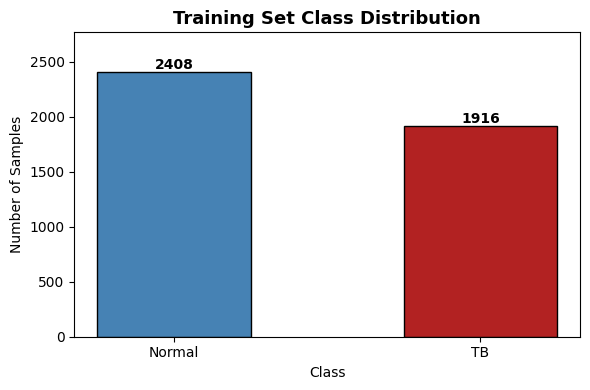


✅ Class distribution chart saved to: eda_results\class_distribution.png

Computing per-class pixel averages...
  Normal samples used for averaging : 2408
  TB samples used for averaging     : 1916


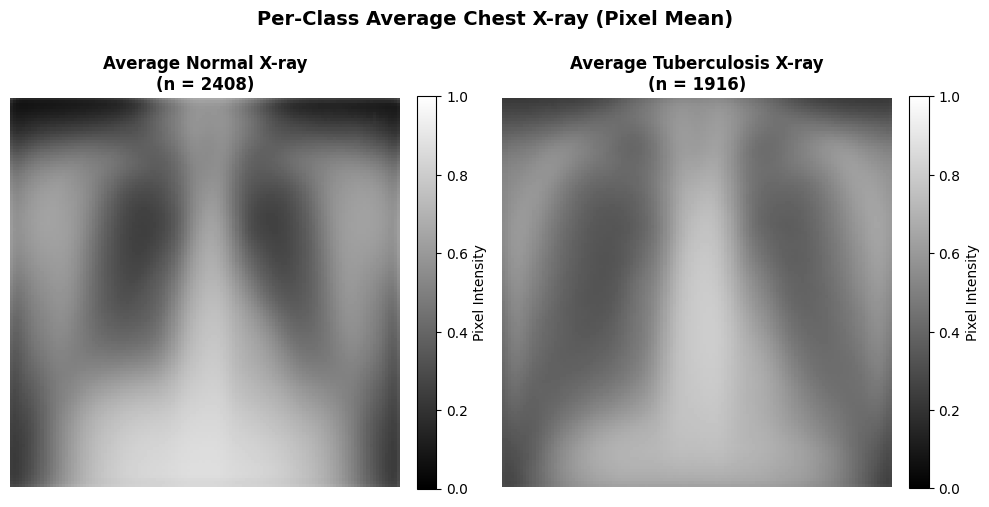

✅ Average X-ray comparison saved to: eda_results\average_xrays_comparison.png

Plotting pixel intensity distributions...


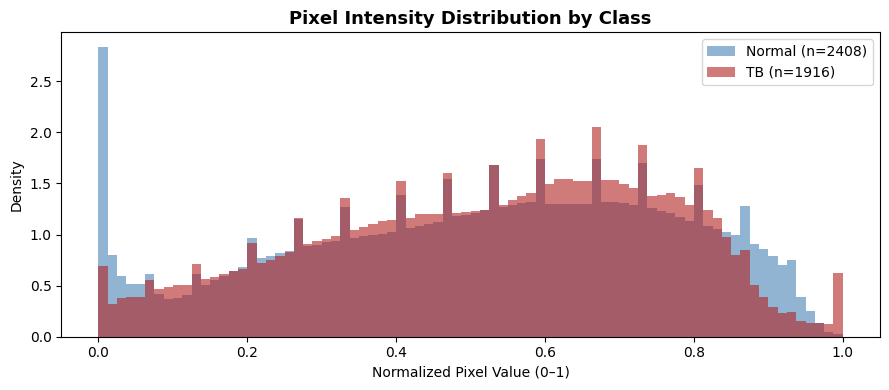

✅ Pixel intensity distribution saved to: eda_results\pixel_intensity_distribution.png

Generating difference map (TB - Normal)...


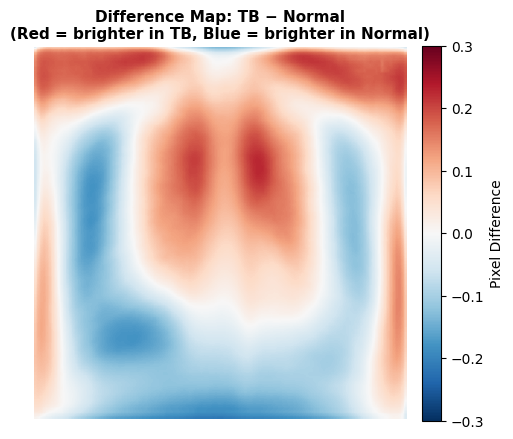

✅ Difference map saved to: eda_results\difference_map.png

✅ EDA complete. All assets saved to: eda_results


In [6]:
# Step 2.5: Exploratory Data Analysis (EDA)
# Analyzes training data BEFORE model fitting to visualize class-level pixel patterns.
# Produces average X-ray images per class and additional distribution plots.

import os
EDA_OUTPUT_DIR = 'eda_results'
os.makedirs(EDA_OUTPUT_DIR, exist_ok=True)

print("="*60)
print("Exploratory Data Analysis (EDA) Pipeline")
print("="*60)

# ------------------------------------------------------------------
# 1. Class Distribution
# ------------------------------------------------------------------
class_counts = {label: int(np.sum(y_train == val)) for label, val in [('Normal', 0), ('TB', 1)]}
print(f"\nTraining set class distribution:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count} samples")

fig_dist, ax_dist = plt.subplots(figsize=(6, 4))
bars = ax_dist.bar(class_counts.keys(), class_counts.values(),
                   color=['steelblue', 'firebrick'], edgecolor='black', width=0.5)
for bar, count in zip(bars, class_counts.values()):
    ax_dist.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(count), ha='center', va='bottom', fontweight='bold')
ax_dist.set_title('Training Set Class Distribution', fontsize=13, fontweight='bold')
ax_dist.set_xlabel('Class')
ax_dist.set_ylabel('Number of Samples')
ax_dist.set_ylim(0, max(class_counts.values()) * 1.15)
plt.tight_layout()
dist_path = os.path.join(EDA_OUTPUT_DIR, 'class_distribution.png')
plt.savefig(dist_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Class distribution chart saved to: {dist_path}")

# ------------------------------------------------------------------
# 2. Average X-ray Images per Class
# ------------------------------------------------------------------
print("\nComputing per-class pixel averages...")

normal_samples = X_train[y_train == 0]
tb_samples     = X_train[y_train == 1]

print(f"  Normal samples used for averaging : {len(normal_samples)}")
print(f"  TB samples used for averaging     : {len(tb_samples)}")

mean_normal_img = np.mean(normal_samples, axis=0).reshape(IMG_SIZE, IMG_SIZE)
mean_tb_img     = np.mean(tb_samples,     axis=0).reshape(IMG_SIZE, IMG_SIZE)

fig_avg, axes_avg = plt.subplots(1, 2, figsize=(10, 5))

im0 = axes_avg[0].imshow(mean_normal_img, cmap='gray', vmin=0, vmax=1)
axes_avg[0].set_title(f'Average Normal X-ray\n(n = {len(normal_samples)})',
                       fontsize=12, fontweight='bold')
axes_avg[0].axis('off')
plt.colorbar(im0, ax=axes_avg[0], fraction=0.046, pad=0.04, label='Pixel Intensity')

im1 = axes_avg[1].imshow(mean_tb_img, cmap='gray', vmin=0, vmax=1)
axes_avg[1].set_title(f'Average Tuberculosis X-ray\n(n = {len(tb_samples)})',
                       fontsize=12, fontweight='bold')
axes_avg[1].axis('off')
plt.colorbar(im1, ax=axes_avg[1], fraction=0.046, pad=0.04, label='Pixel Intensity')

fig_avg.suptitle('Per-Class Average Chest X-ray (Pixel Mean)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
avg_path = os.path.join(EDA_OUTPUT_DIR, 'average_xrays_comparison.png')
plt.savefig(avg_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Average X-ray comparison saved to: {avg_path}")

# ------------------------------------------------------------------
# 3. Pixel Intensity Distribution per Class
# ------------------------------------------------------------------
print("\nPlotting pixel intensity distributions...")

fig_hist, ax_hist = plt.subplots(figsize=(9, 4))
ax_hist.hist(normal_samples.flatten(), bins=80, alpha=0.6, color='steelblue',
             label=f'Normal (n={len(normal_samples)})', density=True)
ax_hist.hist(tb_samples.flatten(),     bins=80, alpha=0.6, color='firebrick',
             label=f'TB (n={len(tb_samples)})',     density=True)
ax_hist.set_title('Pixel Intensity Distribution by Class', fontsize=13, fontweight='bold')
ax_hist.set_xlabel('Normalized Pixel Value (0–1)')
ax_hist.set_ylabel('Density')
ax_hist.legend()
plt.tight_layout()
hist_path = os.path.join(EDA_OUTPUT_DIR, 'pixel_intensity_distribution.png')
plt.savefig(hist_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Pixel intensity distribution saved to: {hist_path}")

# ------------------------------------------------------------------
# 4. Difference Map: TB minus Normal
# ------------------------------------------------------------------
print("\nGenerating difference map (TB - Normal)...")

diff_img = mean_tb_img - mean_normal_img  # signed difference

fig_diff, ax_diff = plt.subplots(figsize=(5, 5))
im_diff = ax_diff.imshow(diff_img, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
ax_diff.set_title('Difference Map: TB − Normal\n(Red = brighter in TB, Blue = brighter in Normal)',
                   fontsize=11, fontweight='bold')
ax_diff.axis('off')
plt.colorbar(im_diff, ax=ax_diff, fraction=0.046, pad=0.04, label='Pixel Difference')
plt.tight_layout()
diff_path = os.path.join(EDA_OUTPUT_DIR, 'difference_map.png')
plt.savefig(diff_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Difference map saved to: {diff_path}")

print("\n" + "="*60)
print("✅ EDA complete. All assets saved to:", EDA_OUTPUT_DIR)
print("="*60)


In [6]:
# Step 3: Train the Model
print("\n" + "="*60)
print("Training Logistic Regression Model")
print("="*60)

model = LogisticRegression(
    max_iter=2000, 
    class_weight='balanced', 
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all CPU cores
)

print("\nTraining... (This may take a few minutes)")
model.fit(X_train, y_train)
print("✅ Training complete!")


Training Logistic Regression Model

Training... (This may take a few minutes)
✅ Training complete!


In [7]:
# Step 4: Evaluate the Model
print("\n" + "="*60)
print("Evaluating Model")
print("="*60)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n📊 TEST SET RESULTS:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'TB']))


Evaluating Model

📊 TEST SET RESULTS:
  Accuracy:  0.9459 (94.59%)
  Precision: 0.9403 (94.03%)
  Recall:    0.9374 (93.74%)
  F1-Score:  0.9389 (93.89%)

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95       803
          TB       0.94      0.94      0.94       639

    accuracy                           0.95      1442
   macro avg       0.95      0.95      0.95      1442
weighted avg       0.95      0.95      0.95      1442



In [8]:
# Step 6: Save the Model
joblib.dump(model, MODEL_PATH)
print(f"\n✅ Model saved to: {MODEL_PATH}")

print("\n" + "="*60)
print("MEDICAL DISCLAIMER")
print("="*60)
print("This model is a Decision Support Tool ONLY.")
print("It may produce false positives and false negatives.")
print("ALWAYS consult qualified medical professionals for diagnosis.")
print("="*60)


✅ Model saved to: tb_linear_model.pkl

MEDICAL DISCLAIMER
This model is a Decision Support Tool ONLY.
It may produce false positives and false negatives.
ALWAYS consult qualified medical professionals for diagnosis.



Confusion Matrix:
[[765  38]
 [ 40 599]]
  True Negatives:  765
  False Positives: 38
  False Negatives: 40
  True Positives:  599

✅ Confusion matrix saved to: confusion_matrix.png


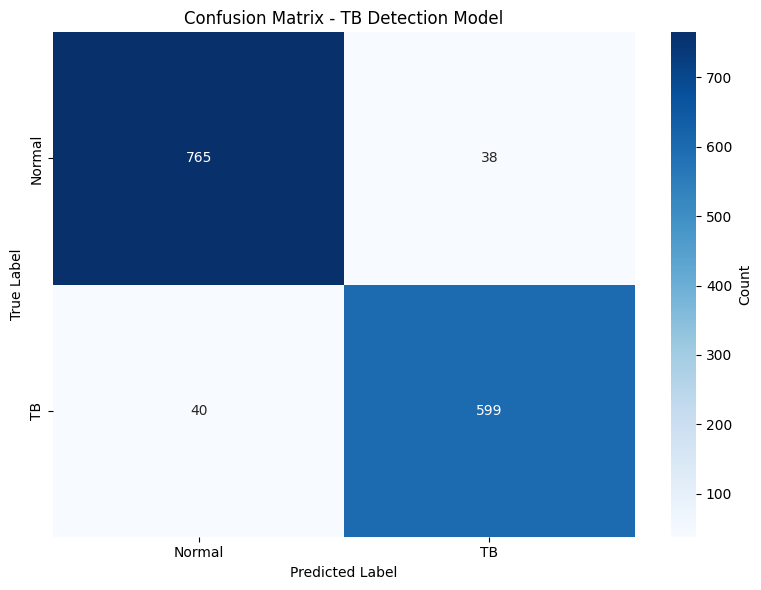

In [9]:
# Step 5: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)
print(f"  True Negatives:  {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives:  {cm[1, 1]}")

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'TB'], 
            yticklabels=['Normal', 'TB'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - TB Detection Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
print("\n✅ Confusion matrix saved to: confusion_matrix.png")
plt.show()

In [10]:
# Step 7: Export Results to CSV
import pandas as pd

# Create a dataframe with predictions and actual labels
results_df = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Label': y_pred,
    'Actual_Class': ['Normal' if label == 0 else 'TB' for label in y_test],
    'Predicted_Class': ['Normal' if label == 0 else 'TB' for label in y_pred],
    'Correct': y_test == y_pred
})

# Save to CSV
csv_path = 'tb_detection_results.csv'
results_df.to_csv(csv_path, index=False)

print(f"\n✅ Results exported to: {csv_path}")
print(f"\nFirst 10 results:")
print(results_df.head(10))
print(f"\nTotal records: {len(results_df)}")
print(f"Correct predictions: {(results_df['Correct']).sum()} / {len(results_df)}")


✅ Results exported to: tb_detection_results.csv

First 10 results:
   Actual_Label  Predicted_Label Actual_Class Predicted_Class  Correct
0             1                1           TB              TB     True
1             0                0       Normal          Normal     True
2             0                1       Normal              TB    False
3             1                1           TB              TB     True
4             0                0       Normal          Normal     True
5             0                0       Normal          Normal     True
6             1                1           TB              TB     True
7             1                1           TB              TB     True
8             0                0       Normal          Normal     True
9             0                0       Normal          Normal     True

Total records: 1442
Correct predictions: 1364 / 1442
